In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 1. Data Loading & Preprocessing
sp500_data = yf.download('^GSPC', start='2020-01-01', end='2024-01-01',multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
sp500_data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000


In [4]:
sp500_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

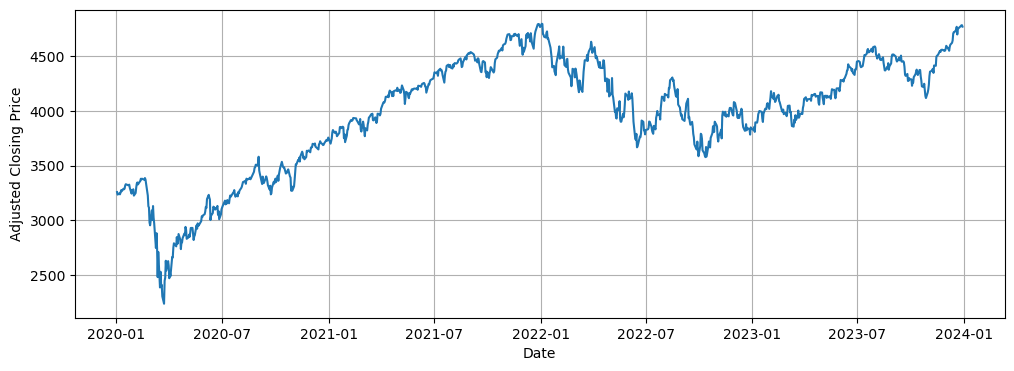

In [6]:
# Plot the original time series data
plt.figure(figsize=(12, 4))
plt.plot(sp500_data["Close"])
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price')
plt.grid(True)
plt.show()

In [ ]:
ARIMA -> p,d,q

In [7]:
def check_stationarity(series, test_name):
    """
    Performs and prints the results of the ADF and KPSS tests.
    
    Args:
        series (pd.Series): The time series to test.
        test_name (str): A descriptive name for the series being tested.
    """
    print(f"\n--- Results for the {test_name} series ---")
    
    # Augmented Dickey-Fuller (ADF) Test
    # H0: The series is non-stationary (has a unit root)
    adf_result = adfuller(series)
    print("ADF Test:")
    print(f"  Test Statistic: {adf_result[0]:.4f}")
    print(f"  P-value: {adf_result[1]:.4f}")
    print("  Interpretation:")
    if adf_result[1] > 0.05:
        print("  --> Fails to reject H0. The series is likely non-stationary.")
    else:
        print("  --> Rejects H0. The series is likely stationary.")
    
    # Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
    # H0: The series is stationary
    try:
        kpss_result = kpss(series, regression='c')
        print("\nKPSS Test:")
        print(f"  Test Statistic: {kpss_result[0]:.4f}")
        print(f"  P-value: {kpss_result[1]:.4f}")
        print("  Interpretation:")
        if kpss_result[1] < 0.05:
            print("  --> Rejects H0. The series is likely non-stationary.")
        else:
            print("  --> Fails to reject H0. The series is likely stationary.")
    except Exception as e:
        print("\nKPSS Test could not be performed due to an error:")
        print(f"  Error: {e}")

In [8]:
check_stationarity(sp500_data['Close'],"Original")


--- Results for the Original series ---
ADF Test:
  Test Statistic: -1.4068
  P-value: 0.5790
  Interpretation:
  --> Fails to reject H0. The series is likely non-stationary.

KPSS Test:
  Test Statistic: 2.6202
  P-value: 0.0100
  Interpretation:
  --> Rejects H0. The series is likely non-stationary.


In [13]:
check_stationarity(np.log(sp500_data['Close']),"Original")


--- Results for the Original series ---
ADF Test:
  Test Statistic: -1.5790
  P-value: 0.4941
  Interpretation:
  --> Fails to reject H0. The series is likely non-stationary.

KPSS Test:
  Test Statistic: 2.6579
  P-value: 0.0100
  Interpretation:
  --> Rejects H0. The series is likely non-stationary.


In [14]:
check_stationarity(sp500_data['Close'].diff().dropna(),"Original")


--- Results for the Original series ---
ADF Test:
  Test Statistic: -9.6996
  P-value: 0.0000
  Interpretation:
  --> Rejects H0. The series is likely stationary.

KPSS Test:
  Test Statistic: 0.0726
  P-value: 0.1000
  Interpretation:
  --> Fails to reject H0. The series is likely stationary.


In [ ]:
d = 1

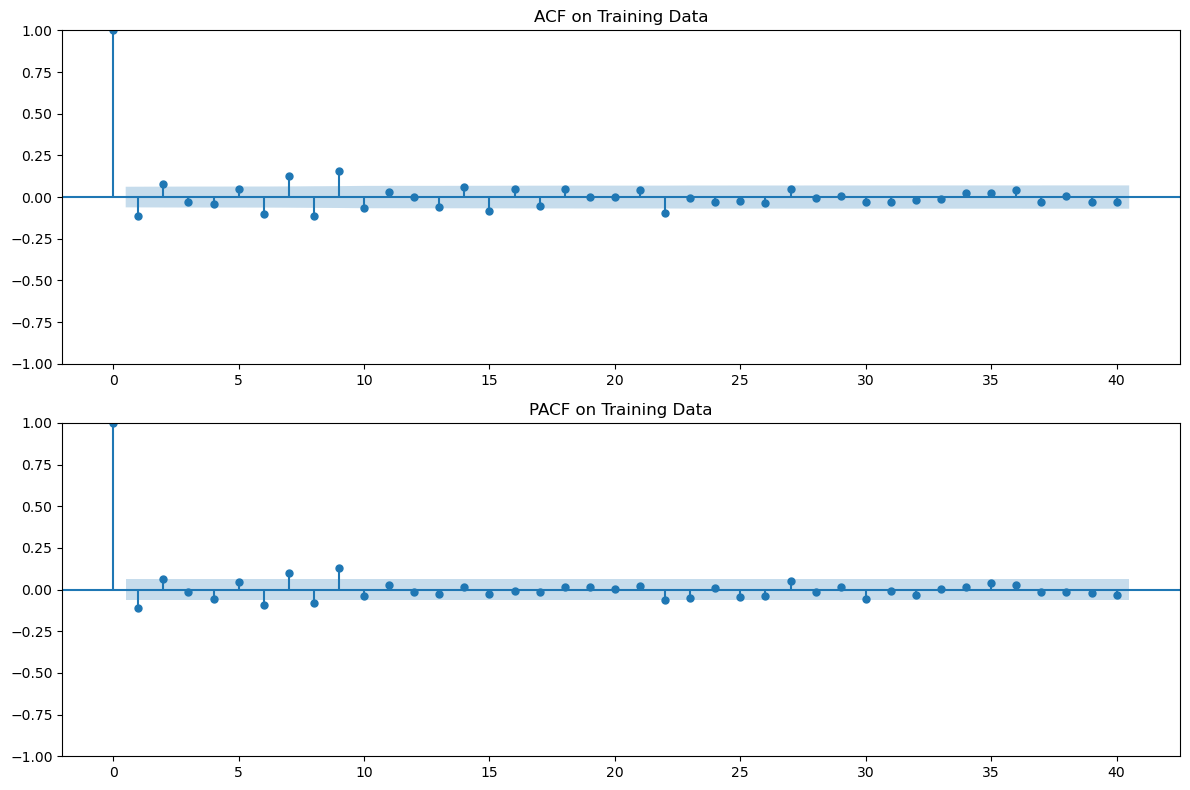

In [15]:
# 3. Model Identification (on Training Data)
# This step is the same as before, but it's crucial to only use the training data
# to identify the model orders (p, q).
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(sp500_data['Close'].diff().dropna(), lags=40, ax=ax1, title='ACF on Training Data')
plot_pacf(sp500_data['Close'].diff().dropna(), lags=40, ax=ax2, title='PACF on Training Data')
plt.tight_layout()
plt.show()



In [ ]:
p = 2
d = 1
q = 2

In [16]:
# 2. Train-Test Split
# Define the size of the test set (e.g., last 100 days)
test_size = 100
train_data = sp500_data['Close'][:-test_size]
test_data = sp500_data['Close'][-test_size:]

print(f"Training data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")


Training data size: 906
Test data size: 100


In [17]:
# Based on a typical analysis, we choose p=1, q=1.
p = 2
q = 2
d = 1

# 4. Model Fitting
# Fit the ARMA(p, q) model to the training data.
print(f"\n--- Fitting ARMA({p}, {q}) Model on Training Data ---")
model = ARIMA(train_data, order=(p, d, q))
results = model.fit()


--- Fitting ARMA(2, 2) Model on Training Data ---


In [18]:
results.summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  906
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4821.703
Date:                Sat, 23 Aug 2025   AIC                           9653.407
Time:                        17:28:15   BIC                           9677.446
Sample:                             0   HQIC                          9662.588
                                - 906                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7603      0.035    -51.007      0.000      -1.828      -1.693
ar.L2         -0.8857      0.032    -27.525      0.000      -0.949      -0.823
ma.L1          1.6750      0.045     37.388      0.000       1.587       1.763
ma.L2          0.7767      0.042     18.374      0.000       0.694       0.860
sigma2      2483.5566     82.428     30.130      0.000    2322.001    2645.113
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):               300.39
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.88   Skew:                            -0.57
Prob(H) (two-sided):                  0.28   Kurtosis:                         5.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
# 5. Forecasting and Performance Comparison
# Forecast the next 'test_size' steps to compare against the test set.
forecast_result = results.get_forecast(steps=test_size)
forecast_mean = forecast_result.predicted_mean

In [23]:
forecast_mean

906     4494.843219
907     4502.715762
908     4492.876142
909     4503.223775
910     4493.724122
           ...     
1001    4498.097259
1002    4498.116909
1003    4498.089235
1004    4498.120545
1005    4498.089943
Name: predicted_mean, Length: 100, dtype: float64

In [24]:
test_data

Date
2023-08-09    4467.709961
2023-08-10    4468.830078
2023-08-11    4464.049805
2023-08-14    4489.720215
2023-08-15    4437.859863
                 ...     
2023-12-22    4754.629883
2023-12-26    4774.750000
2023-12-27    4781.580078
2023-12-28    4783.350098
2023-12-29    4769.830078
Name: Close, Length: 100, dtype: float64

In [11]:
# sp500_series = sp500_data['Close']
# log_returns = np.log(sp500_series / sp500_series.shift(1)).dropna()
sp500_series = sp500_data['Close']
returns = sp500_series / sp500_series.shift(1)
returns.dropna(inplace=True)

In [12]:
check_stationarity(returns,"Original")


--- Results for the Original series ---
ADF Test:
  Test Statistic: -9.4603
  P-value: 0.0000
  Interpretation:
  --> Rejects H0. The series is likely stationary.

KPSS Test:
  Test Statistic: 0.0681
  P-value: 0.1000
  Interpretation:
  --> Fails to reject H0. The series is likely stationary.


In [ ]:
# 2. Train-Test Split
# Define the size of the test set (e.g., last 100 days)
test_size = 100
train_data = log_returns[:-test_size]
test_data = log_returns[-test_size:]

print(f"Training data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")


In [ ]:
# 3. Model Identification (on Training Data)
# This step is the same as before, but it's crucial to only use the training data
# to identify the model orders (p, q).
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_data, lags=40, ax=ax1, title='ACF on Training Data')
plot_pacf(train_data, lags=40, ax=ax2, title='PACF on Training Data')
plt.tight_layout()
plt.show()



In [ ]:
# Based on a typical analysis, we choose p=1, q=1.
p = 2
q = 2

# 4. Model Fitting
# Fit the ARMA(p, q) model to the training data.
print(f"\n--- Fitting ARMA({p}, {q}) Model on Training Data ---")
model = ARIMA(train_data, order=(p, 0, q))
results = model.fit()

In [ ]:
# 5. Forecasting and Performance Comparison
# Forecast the next 'test_size' steps to compare against the test set.
forecast_result = results.get_forecast(steps=test_size)
forecast_mean = forecast_result.predicted_mean

In [ ]:
list(forecast_mean)

In [ ]:
test_data = pd.DataFrame(test_data)

In [ ]:
test_data["forecast_result"] = list(forecast_mean)

In [ ]:
test_data

In [ ]:
# Convert the test data to a pandas Series to ensure proper alignment

# Calculate performance metrics
mae = mean_absolute_error(test_data["Close"], test_data["forecast_result"])
rmse = np.sqrt(mean_squared_error(test_data["Close"], test_data["forecast_result"]))

print(f"\n--- Model Performance on Test Data ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")



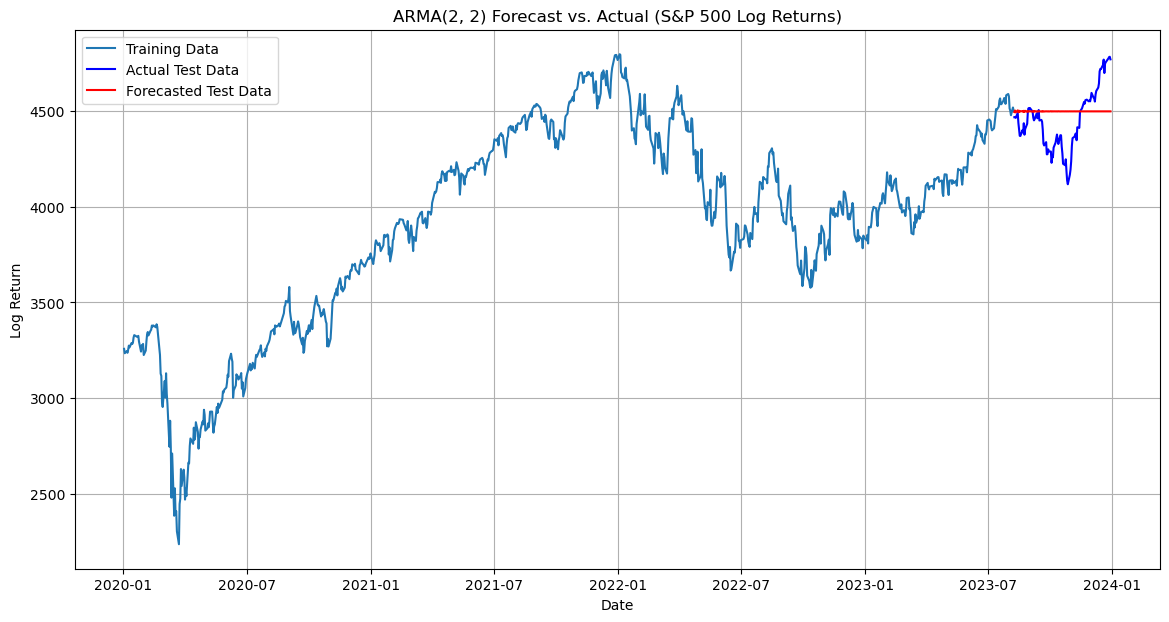

In [27]:
# 6. Visualization of the Forecast vs. Actual
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='blue')
plt.plot(test_data.index, forecast_mean, label='Forecasted Test Data', color='red')
plt.title(f'ARMA({p}, {q}) Forecast vs. Actual (S&P 500 Log Returns)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()